In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import requests
from ira.ingest.ingest_scorecard import save
from ira.clean.clean_scorecard import clean
from ira.config import SCORECARD_KEY, BASE_URL
import math
import json
import time

root = Path.cwd()/'institutional-roi-analysis'
# os.chdir(root/"Seb_branch"/"institutional-roi-analysis"/"notebooks")
pd.set_option("display.max_columns",None)
display(root)

WindowsPath('C:/Users/sebas/PycharmProjects/Git/Seb_branch/institutional-roi-analysis')

In [308]:
residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_residual_FL_stable_programs.csv")
ipedsd_df = pd.read_csv(root/"data"/"clean"/"ipeds"/"clean_ipeds_drivers.csv")

In [309]:
residual_df.head()

,code,credential_level,unit_id,distance,school_type,5_yr_working_count,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score
0,301,3,133492,1,"Private, nonprofit",56.0,27.715798,-82.687043,11,11,0.7580,77695.0,0.411392,2.0,21.0,1,open,10.662914,10.643175,Natural Resources Conservation and Research.,Eckerd College,42741.0,41905.617,835.382813,39932.0,10.594933,50566.960,10.831054,-10634.960938,77,25709.0,10.154596,29107.588,10.278754,-3398.587891,94.0,8,medium,-0.116760,-0.115420,-0.210314,-0.207225,0.019935,0.019527,6.0,8.0,3.0,2.0,-5.0,-3.0,2.516611,0.359516,0.250313,-0.115420
1,301,3,133951,2,Public,36.0,25.757320,-80.373928,21,15,0.5466,23924.0,0.813127,2.0,23.0,1,mid,10.745076,10.783957,Natural Resources Conservation and Research.,Florida International University,46401.0,48240.610,-1839.609375,49748.0,10.814726,55158.484,10.917966,-5410.484375,24,36007.0,10.491469,33721.535,10.425892,2285.464844,21.0,8,medium,0.067775,0.063452,-0.098090,-0.092620,-0.038134,-0.036835,2.0,7.0,6.0,5.0,-1.0,4.0,2.645751,0.377964,0.250313,-0.036835
2,301,3,134097,1,Public,78.0,30.443147,-84.295064,12,15,0.2422,43729.0,0.597532,2.0,20.0,1,elite,10.780705,10.786012,Natural Resources Conservation and Research.,Florida State University,48084.0,48339.850,-255.851562,54288.0,10.902058,52498.200,10.868534,1789.800781,188,30146.0,10.313808,36875.710,10.515308,-6729.710937,161.0,8,medium,-0.182497,-0.181380,0.034093,0.033916,-0.005293,-0.005219,7.0,5.0,5.0,-2.0,0.0,-2.0,1.154701,0.164957,0.250313,-0.005219
3,301,3,134130,1,Public,28.0,29.646290,-82.347911,12,16,0.2420,39127.0,0.667383,2.0,21.0,1,elite,10.895108,10.878085,Natural Resources Conservation and Research.,University of Florida,53912.0,53002.010,909.988281,62683.0,11.045846,57587.316,10.961058,5095.683594,29,34454.0,10.447380,36076.906,10.493408,-1622.906250,29.0,8,medium,-0.044985,-0.042980,0.088486,0.084491,0.017169,0.016391,5.0,3.0,4.0,-2.0,1.0,-1.0,1.000000,0.142857,0.250313,0.016391
4,301,3,136950,1,"Private, nonprofit",29.0,28.592787,-81.349239,21,11,0.4754,43978.0,0.580000,2.0,22.0,1,mid,10.517050,10.832608,Natural Resources Conservation and Research.,Rollins College,36940.0,50645.630,-13705.628906,63363.0,11.056635,52899.145,10.876143,10463.855469,23,22352.0,10.014671,34313.710,10.443300,-11961.710937,18.0,8,medium,-0.348599,-0.322316,0.197808,0.186247,-0.270618,-0.258835,8.0,2.0,8.0,-6.0,6.0,0.0,3.464102,0.494872,0.250313,-0.258835


In [310]:
# compute pct error at row level in dollar space
residual_df["dollar_error_median"] = residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1)

residual_df["dollar_pred_median"] = residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].median(axis=1)

residual_df["row_pct_error"] = (
    residual_df["dollar_error_median"] / residual_df["dollar_pred_median"]
)

In [311]:
school_df = residual_df.groupby("unit_id", as_index=False).agg(
    combined_pct_error=("row_pct_error", "median"),
    avg_rank_stability=("mean_rank_std_pct", "mean"),
    school_name=("school_name", "first"),
    total_count_1=("1_yr_working_count", "sum"),
    total_count_4=("4_yr_working_count", "sum"),
    total_count_5=("5_yr_working_count", "sum"),
)

school_df["total_count"] = (
    school_df["total_count_1"] +
    school_df["total_count_4"] +
    school_df["total_count_5"]
)

k = np.percentile(np.log1p(school_df["total_count"]), 75)
school_df["weight"] = (
    np.log1p(school_df["total_count"]) /
    np.log1p(school_df["total_count"] + k)
)

In [312]:
ipedsd_df=ipedsd_df.drop(columns=[
    'program_completer_share_within_school','program_completers',
    'program_completers_log',"credential_level",'code',
#     # 'unit_id',
#     'school_name'
    ]
)

In [313]:
ipedsd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6909 entries, 0 to 6908
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   6909 non-null   int64  
 1   year                                      6909 non-null   int64  
 2   instruction_salary_pct                    0 non-null      float64
 3   academic_support_salary_pct               0 non-null      float64
 4   student_services_salary_pct               0 non-null      float64
 5   research_salary_pct                       0 non-null      float64
 6   no_ap_credit                              6909 non-null   float64
 7   study_abroad                              6909 non-null   float64
 8   career_counseling                         6909 non-null   float64
 9   employment_services                       6909 non-null   float64
 10  placement_services                  

In [314]:
ipedsd_df=ipedsd_df.drop(columns=['instruction_salary_pct', 'academic_support_salary_pct',
       'student_services_salary_pct', 'research_salary_pct','year'])

In [315]:
targ="combined_pct_error"
merge_df=ipedsd_df.merge(school_df[[targ,'unit_id','weight','avg_rank_stability','school_name']], on=["unit_id"],how="inner")
merge_df.head()

,unit_id,no_ap_credit,study_abroad,career_counseling,employment_services,placement_services,instruction_expense_pct,research_expense_pct,student_service_expense_pct,endowment_per_fte,equity_ratio,staff_per_student,instructional_fte_per_student,irps_fte_per_student,instructional_share_of_staff,research_share_of_staff,instructional_staff_total,instructional_staff_short_contract,instructional_staff_long_contract,instructional_staff_long_contract_share,instructional_staff_short_contract_share,combined_pct_error,weight,avg_rank_stability,school_name
0,132471,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.102841,0.043977,0.043977,0.427624,0.0,550.0,0.0,550.0,1.0,0.0,-0.031149,0.999852,0.124632,Barry University
1,132471,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.102841,0.043977,0.043977,0.427624,0.0,550.0,0.0,550.0,1.0,0.0,-0.031149,0.999852,0.124632,Barry University
2,132471,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.102841,0.043977,0.043977,0.427624,0.0,550.0,0.0,550.0,1.0,0.0,-0.031149,0.999852,0.124632,Barry University
3,132471,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.102841,0.043977,0.043977,0.427624,0.0,550.0,0.0,550.0,1.0,0.0,-0.031149,0.999852,0.124632,Barry University
4,132471,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.102841,0.043977,0.043977,0.427624,0.0,550.0,0.0,550.0,1.0,0.0,-0.031149,0.999852,0.124632,Barry University


In [316]:
model_df=merge_df.copy()
print("ipeds driver schools:", ipedsd_df['unit_id'].nunique())
print("school_df school:", school_df['unit_id'].nunique())
print("model_df schools:", model_df['unit_id'].nunique())

print("ipeds driver schools:", ipedsd_df.shape)
print("school_df school:", school_df.shape)
print("model_df schools:", model_df.shape)

print("model_df columns:")
print(sorted(model_df.columns.tolist()))

ipeds driver schools: 314
school_df school: 200
model_df schools: 193
ipeds driver schools: (6909, 21)
school_df school: (200, 9)
model_df schools: (6029, 25)
model_df columns:
['avg_rank_stability', 'career_counseling', 'combined_pct_error', 'employment_services', 'endowment_per_fte', 'equity_ratio', 'instruction_expense_pct', 'instructional_fte_per_student', 'instructional_share_of_staff', 'instructional_staff_long_contract', 'instructional_staff_long_contract_share', 'instructional_staff_short_contract', 'instructional_staff_short_contract_share', 'instructional_staff_total', 'irps_fte_per_student', 'no_ap_credit', 'placement_services', 'research_expense_pct', 'research_share_of_staff', 'school_name', 'staff_per_student', 'student_service_expense_pct', 'study_abroad', 'unit_id', 'weight']


In [317]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6029 entries, 0 to 6028
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   6029 non-null   int64  
 1   no_ap_credit                              6029 non-null   float64
 2   study_abroad                              6029 non-null   float64
 3   career_counseling                         6029 non-null   float64
 4   employment_services                       6029 non-null   float64
 5   placement_services                        6029 non-null   float64
 6   instruction_expense_pct                   3713 non-null   float64
 7   research_expense_pct                      3713 non-null   float64
 8   student_service_expense_pct               3713 non-null   float64
 9   endowment_per_fte                         3347 non-null   float64
 10  equity_ratio                        

In [318]:
display("Repeated columns within instituions",(model_df.groupby("unit_id").nunique() > 1).sum())
display("Feature correlation to target variable",model_df.corr()[targ].sort_values())

'Repeated columns within instituions'

no_ap_credit                                0
study_abroad                                0
career_counseling                           0
employment_services                         0
placement_services                          0
instruction_expense_pct                     0
research_expense_pct                        0
student_service_expense_pct                 0
endowment_per_fte                           0
equity_ratio                                0
staff_per_student                           0
instructional_fte_per_student               0
irps_fte_per_student                        0
instructional_share_of_staff                0
research_share_of_staff                     0
instructional_staff_total                   0
instructional_staff_short_contract          0
instructional_staff_long_contract           0
instructional_staff_long_contract_share     0
instructional_staff_short_contract_share    0
combined_pct_error                          0
weight                            

C:\Users\sebas\AppData\Local\Temp\ipykernel_23580\703387114.py:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



'Feature correlation to target variable'

endowment_per_fte                          -0.231756
study_abroad                               -0.180563
research_expense_pct                       -0.174843
staff_per_student                          -0.161587
equity_ratio                               -0.146494
irps_fte_per_student                       -0.142211
instructional_fte_per_student              -0.116850
instructional_staff_long_contract_share    -0.109151
weight                                     -0.105734
research_share_of_staff                    -0.097683
instructional_staff_long_contract          -0.075983
instructional_staff_total                  -0.075626
avg_rank_stability                         -0.070840
placement_services                         -0.058392
career_counseling                          -0.024268
unit_id                                     0.008126
instructional_staff_short_contract          0.020171
student_service_expense_pct                 0.051250
employment_services                         0.

In [320]:
inst_model_df = model_df.drop_duplicates(subset="unit_id").reset_index(drop=True)
print("inst_model_df shape:", inst_model_df.shape)
display(inst_model_df.info())

inst_model_df shape: (193, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   193 non-null    int64  
 1   no_ap_credit                              193 non-null    float64
 2   study_abroad                              193 non-null    float64
 3   career_counseling                         193 non-null    float64
 4   employment_services                       193 non-null    float64
 5   placement_services                        193 non-null    float64
 6   instruction_expense_pct                   61 non-null     float64
 7   research_expense_pct                      61 non-null     float64
 8   student_service_expense_pct               61 non-null     float64
 9   endowment_per_fte                         39 non-null     float64
 10  equity_

None

In [287]:
display(inst_model_df.describe())
display("Feature correlation to target variable",inst_model_df.corr()[targ].sort_values())
display(inst_model_df.info())

,unit_id,no_ap_credit,study_abroad,career_counseling,employment_services,placement_services,instruction_expense_pct,research_expense_pct,student_service_expense_pct,endowment_per_fte,equity_ratio,staff_per_student,instructional_fte_per_student,irps_fte_per_student,instructional_share_of_staff,research_share_of_staff,instructional_staff_total,instructional_staff_short_contract,instructional_staff_long_contract,instructional_staff_long_contract_share,instructional_staff_short_contract_share,combined_pct_error,weight,avg_rank_stability
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,61.000000,61.000000,61.000000,39.000000,40.0000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,109.000000,109.000000,1.930000e+02,193.000000,193.000000
mean,293866.093264,0.424870,0.284974,0.943005,0.751295,0.922280,42.459016,2.245902,9.721311,7285.923077,65.3750,0.099721,0.039760,0.040518,0.431906,0.001920,268.000000,1.523316,266.476684,0.990716,0.009284,6.000863e-09,0.996449,0.171677
std,154755.347105,0.495609,0.452576,0.232436,0.433386,0.268427,11.152838,5.786927,4.207656,10246.626547,14.5297,0.097442,0.033466,0.034334,0.114889,0.008556,642.801259,17.253645,641.126629,0.043407,0.043407,3.029170e-07,0.005558,0.062967
min,132471.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,227.000000,37.0000,0.016738,0.007823,0.007823,0.131088,0.000000,0.000000,0.000000,0.000000,0.708333,0.000000,-9.908899e-07,0.969471,0.047313
25%,135276.000000,0.000000,0.000000,1.000000,1.000000,1.000000,36.000000,0.000000,7.000000,1677.500000,58.0000,0.052701,0.021183,0.021183,0.357143,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-3.927926e-08,0.995770,0.119940
50%,366553.000000,0.000000,0.000000,1.000000,1.000000,1.000000,38.000000,0.000000,10.000000,4389.000000,67.5000,0.072720,0.033662,0.033662,0.430730,0.000000,14.000000,0.000000,12.000000,1.000000,0.000000,-2.342890e-10,0.998696,0.163766
75%,449083.000000,1.000000,1.000000,1.000000,1.000000,1.000000,49.000000,0.000000,13.000000,8313.500000,76.0000,0.110145,0.050245,0.050538,0.510417,0.000000,248.000000,0.000000,248.000000,1.000000,0.000000,5.278544e-08,0.999651,0.244641
max,495369.000000,1.000000,1.000000,1.000000,1.000000,1.000000,73.000000,25.000000,18.000000,55596.000000,89.0000,0.937500,0.375000,0.375000,0.723684,0.063864,5044.000000,238.000000,5044.000000,1.000000,0.291667,1.490142e-06,0.999977,0.270640


C:\Users\sebas\AppData\Local\Temp\ipykernel_23580\3989557815.py:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



'Feature correlation to target variable'

endowment_per_fte                          -0.750188
student_service_expense_pct                -0.224821
weight                                     -0.174721
avg_rank_stability                         -0.148489
research_expense_pct                       -0.083798
study_abroad                               -0.071921
instructional_share_of_staff               -0.046200
career_counseling                          -0.042241
instructional_staff_long_contract_share    -0.022365
instructional_staff_long_contract          -0.017341
instructional_staff_total                  -0.017306
research_share_of_staff                    -0.004932
no_ap_credit                               -0.002503
instructional_staff_short_contract         -0.000377
staff_per_student                           0.019588
irps_fte_per_student                        0.021734
instructional_staff_short_contract_share    0.022365
instructional_fte_per_student               0.022827
placement_services                          0.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   unit_id                                   193 non-null    int64  
 1   no_ap_credit                              193 non-null    float64
 2   study_abroad                              193 non-null    float64
 3   career_counseling                         193 non-null    float64
 4   employment_services                       193 non-null    float64
 5   placement_services                        193 non-null    float64
 6   instruction_expense_pct                   61 non-null     float64
 7   research_expense_pct                      61 non-null     float64
 8   student_service_expense_pct               61 non-null     float64
 9   endowment_per_fte                         39 non-null     float64
 10  equity_ratio                          

None

In [262]:
inst_model_df.columns

Index(['unit_id', 'no_ap_credit', 'study_abroad', 'career_counseling',
       'employment_services', 'placement_services', 'instruction_expense_pct',
       'research_expense_pct', 'student_service_expense_pct',
       'endowment_per_fte', 'equity_ratio', 'staff_per_student',
       'instructional_fte_per_student', 'irps_fte_per_student',
       'instructional_share_of_staff', 'research_share_of_staff',
       'instructional_staff_total', 'instructional_staff_short_contract',
       'instructional_staff_long_contract',
       'instructional_staff_long_contract_share',
       'instructional_staff_short_contract_share', 'combined_pct_error',
       'weight', 'avg_rank_stability', 'school_name'],
      dtype='object')

In [263]:
import plotly.express as px
px.histogram(inst_model_df[targ])

In [264]:
inst_model_df[targ].skew()

0.0

In [265]:
inst_model_df[targ].describe()

count    1.930000e+02
mean     6.000863e-09
std      3.029170e-07
min     -9.908899e-07
25%     -3.927926e-08
50%     -2.342890e-10
75%      5.278544e-08
max      1.490142e-06
Name: combined_pct_error, dtype: float64

In [322]:
def build_target_variants(df):
    d = df.copy()
    
    # raw errors
    e1 = d["1_year_error"]
    e4 = d["4_year_error"]
    e5 = d["5_year_error"]
    
    # counts
    c1 = d["1_yr_working_count"]
    c4 = d["4_yr_working_count"]
    c5 = d["5_yr_working_count"]
    total_count = d["total_count"]
    total_pred  = d["total_pred"]
    
    targets = {}

    # --- pct error variants ---
    targets["pct_sum_over_pred"] = (e1 + e4 + e5) / total_pred

    targets["pct_mean_over_pred"] = (
        (e1/total_pred + e4/total_pred + e5/total_pred) / 3
    )

    targets["pct_count_weighted"] = (
        e1*c1 + e4*c4 + e5*c5
    ) / (total_count * total_pred)

    targets["pct_median_year"] = (
        pd.concat([e1/total_pred, e4/total_pred, e5/total_pred], axis=1)
        .median(axis=1)
    )

    # --- log scale variants ---
    targets["log_error_sum"] = (
        d["1_year_earning_log"] - d["1_year_pred_log"] +
        d["4_year_earning_log"] - d["4_year_pred_log"] +
        d["5_year_earning_log"] - d["5_year_pred_log"]
    )

    targets["log_error_mean"] = targets["log_error_sum"] / 3

    targets["log_error_count_weighted"] = (
        (d["1_year_earning_log"] - d["1_year_pred_log"]) * c1 +
        (d["4_year_earning_log"] - d["4_year_pred_log"]) * c4 +
        (d["5_year_earning_log"] - d["5_year_pred_log"]) * c5
    ) / total_count

    # --- sign-consistent only (mask applied later) ---
    targets["pct_sum_sign_consistent"] = targets["pct_sum_over_pred"].copy()
    sign_mask = (
        (np.sign(e1) == np.sign(e4)) & (np.sign(e4) == np.sign(e5))
    )
    targets["pct_sum_sign_consistent"][~sign_mask] = np.nan

    return targets, sign_mask

def run_school_corr_screen(merge_df, feature_cols, target_col="combined_pct_error", weight_col="weight"):
    
    df_tmp = merge_df[feature_cols + [target_col, weight_col]].copy()
    df_tmp = df_tmp.dropna(subset=[target_col])
    df_tmp = df_tmp.dropna(subset=feature_cols, how="all")
    
    print(f"Rows after dropna: {len(df_tmp)}")
    print(f"Features: {len(feature_cols)}")
    print(f"Target distribution:\n{df_tmp[target_col].describe().round(4)}\n")

    # winsorize target
    lo, hi = df_tmp[target_col].quantile(0.02), df_tmp[target_col].quantile(0.98)
    df_tmp[target_col] = df_tmp[target_col].clip(lo, hi)

    X = df_tmp[feature_cols].apply(pd.to_numeric, errors="coerce")
    y = df_tmp[target_col]
    w = df_tmp[weight_col]

    # ── correlation screen ───────────────────────────────────────
    corr = X.corrwith(y).abs().sort_values(ascending=False)
    
    print("Top 15 correlations with target:")
    print(corr.head(15).round(4).to_string())
    print(f"\nFeatures with |corr| > 0.10: {(corr > 0.10).sum()}")
    print(f"Features with |corr| > 0.15: {(corr > 0.15).sum()}")
    print(f"Features with |corr| > 0.20: {(corr > 0.20).sum()}")

    # ── RF signal check ──────────────────────────────────────────
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import KFold
    from sklearn.metrics import r2_score
    from sklearn.impute import SimpleImputer

    imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100, 
        max_depth=3,        # shallow — only 200 rows
        random_state=42, 
        n_jobs=-1
    )

    fold_r2s = []
    for train_idx, val_idx in kf.split(X_imp):
        X_tr, X_val = X_imp.iloc[train_idx], X_imp.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[train_idx], w.iloc[val_idx]

        rf.fit(X_tr, y_tr, sample_weight=w_tr)
        y_pred = rf.predict(X_val)
        fold_r2s.append(r2_score(y_val, y_pred, sample_weight=w_val))

    print(f"\nRF CV R² (max_depth=3): {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}")
    print(f"Fold R²s: {[round(s,3) for s in fold_r2s]}")

    # ── feature importance if R² is positive ────────────────────
    if np.mean(fold_r2s) > 0:
        rf.fit(X_imp, y, sample_weight=w)
        imp_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": rf.feature_importances_
        }).sort_values("importance", ascending=False)
        print("\nTop 10 feature importances:")
        print(imp_df.head(10).to_string(index=False))

    return corr


# ── RUN ─────────────────────────────────────────────────────────
feature_cols = [c for c in inst_model_df.columns if c not in [
    "unit_id", "school_name", "weight", "combined_pct_error",
    "avg_rank_stability", "total_pred", "median_error",
    "total_count", "total_count_1", "total_count_4", "total_count_5"
]]

corr_results = run_school_corr_screen(inst_model_df, feature_cols)

Rows after dropna: 193
Features: 20
Target distribution:
count    193.0000
mean       0.0045
std        0.0963
min       -0.4613
25%       -0.0392
50%       -0.0035
75%        0.0378
max        0.4165
Name: combined_pct_error, dtype: float64

Top 15 correlations with target:
endowment_per_fte                           0.5650
instruction_expense_pct                     0.4272
student_service_expense_pct                 0.2066
research_expense_pct                        0.1216
instructional_staff_short_contract_share    0.1192
instructional_staff_long_contract_share     0.1192
study_abroad                                0.1186
employment_services                         0.1155
equity_ratio                                0.0666
career_counseling                           0.0627
instructional_staff_long_contract           0.0577
instructional_staff_total                   0.0574
research_share_of_staff                     0.0461
staff_per_student                           0.0392
irps_fte_p

In [323]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, StratifiedKFold
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42

In [324]:
# -------------------
# 1. Define target
# -------------------

# Drop target and target-like columns from X
feature_cols = [c for c in inst_model_df.columns if c not in ["unit_id", targ, "weight",'credential_level','code','avg_rank_stability']]

X = inst_model_df[feature_cols]

y = np.log1p(inst_model_df[targ].abs())
# y = y.clip(upper=y.quantile(0.9))

w = inst_model_df["weight"]

# Force predictors numeric
X = X.apply(pd.to_numeric, errors="coerce")

# -------------------
# 2. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=RANDOM_STATE
)

# -------------------
# 4. Recompute numeric columns
# -------------------
num_cols = X_train.columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols)
])

In [325]:
len(y)

193

In [327]:
# -------------------
# 5. Ridge model
# -------------------
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Ridge())
])

# ridge_model = TransformedTargetRegressor(
#     regressor=ridge_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

ridge_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

ridge_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

print("RIDGE")
print("Best params:", ridge_grid.best_params_)
print("Best CV MAE:", round(-ridge_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, ridge_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, ridge_preds), 4))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
RIDGE
Best params: {'reg__alpha': 100.0}
Best CV MAE: 0.0457
Test MAE (vs unclipped y_test): 0.0401
Test R2 (vs unclipped y_test): 0.1311


In [335]:
from sklearn.linear_model import Lasso


lasso_param_grid = {
    "reg__alpha": np.logspace(-4, 1, 50)
}

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Lasso(max_iter=10000, random_state=RANDOM_STATE))
])

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

lasso_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

lasso_best = lasso_grid.best_estimator_
lasso_preds = lasso_best.predict(X_test)

print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, lasso_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, lasso_preds), 4))

feature_names = lasso_best.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": [f.replace("num__", "") for f in feature_names],
    "coefficient": lasso_best.named_steps["reg"].coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df[coef_df["coefficient"] != 0].to_string(index=False))
print(f"\nFeatures selected: {(coef_df['coefficient'] != 0).sum()} of {len(coef_df)}")
print(f"Lasso alpha chosen: {lasso_best.named_steps['reg'].alpha:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Test MAE (vs unclipped y_test): 0.0417
Test R2 (vs unclipped y_test): 0.0676
                  feature  coefficient
instructional_staff_total    -0.008670
             study_abroad    -0.006020
        endowment_per_fte     0.001503
  instruction_expense_pct     0.000154

Features selected: 4 of 20
Lasso alpha chosen: 0.0043


In [338]:
from sklearn.linear_model import LassoCV

# stability check — do the same features survive across seeds?
for seed in [0, 7, 13, 21, 99]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("reg", LassoCV(cv=5, random_state=seed, max_iter=10000))
    ])
    pipe.fit(X_train, y_train, reg__sample_weight=w_train)

    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    selected = [
        f.replace("num__", "")
        for f, c in zip(feature_names, pipe.named_steps["reg"].coef_)
        if c != 0
    ]
    print(f"Seed {seed:3d}: {selected}")

Seed   0: ['study_abroad', 'instructional_staff_total']
Seed   7: ['study_abroad', 'instructional_staff_total']
Seed  13: ['study_abroad', 'instructional_staff_total']
Seed  21: ['study_abroad', 'instructional_staff_total']
Seed  99: ['study_abroad', 'instructional_staff_total']


In [339]:
enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", ElasticNet(max_iter=100000))
])

# enet_model = TransformedTargetRegressor(
#     regressor=enet_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

enet_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0],
    "reg__l1_ratio": [0.005,0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=enet_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

enet_grid.fit(
    X_train, 
    y_train,
    reg__sample_weight=w_train
)

enet_best = enet_grid.best_estimator_
enet_preds = enet_best.predict(X_test)

print("\nELASTIC NET")
print("Best params:", enet_grid.best_params_)
print("Best CV MAE:", round(-enet_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, enet_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, enet_preds), 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

ELASTIC NET
Best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.5}
Best CV MAE: 0.0453
Test MAE (vs unclipped y_test): 0.042
Test R2 (vs unclipped y_test): 0.0625


In [138]:
y_pred = [y.mean()] * len(y)

mean_absolute_error(y, y_pred)

0.01565250777982846

In [142]:
from sklearn.ensemble import HistGradientBoostingRegressor

def run_hgbr():
    hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])
    

    hgbr_model.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 
    preds = hgbr_model.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds)) 
    print("R2:", r2_score(y_test, preds))
run_hgbr()

MAE: 0.01494436239648543
R2: 0.12048427556245711


In [143]:
def run_hgbr_2():
    hgbr_model_2 = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor(
        max_depth=5,              # allow more interactions
        learning_rate=0.01,       # slower learning
        max_iter=750,             # more trees
        min_samples_leaf=10,      # regularization
        l2_regularization=2.0,    # stabilize
        random_state=42
        ))
    ])
  

    hgbr_model_2.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 

    preds_2 = hgbr_model_2.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds_2)) 
    print("R2:", r2_score(y_test, preds_2))
run_hgbr_2()

MAE: 0.015691311002134903
R2: 0.03847731600522264


In [145]:
from sklearn.model_selection import cross_val_score

# bin target into quantiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])

scores = cross_val_score(
    cv_hgbr_model,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2"
)

print('HistGradientBoostingRegressor\n',scores)
print("mean:", scores.mean())
print("std:", scores.std())

HistGradientBoostingRegressor
 [-0.19211477 -0.45404861 -0.13811085  0.03124136  0.11989572]
mean: -0.12662742910310118
std: 0.19865614006280075


In [147]:
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

cv_hgbr_model.fit(X_train, y_shuffled.loc[X_train.index], model__sample_weight=w_train)
preds = cv_hgbr_model.predict(X_test)

print("R2 shuffled:", r2_score(y_test, preds))

R2 shuffled: 0.04095414514787843


In [148]:
# bin target into quantiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    ridge_pipe,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2",
    fit_params={"reg__sample_weight": w}
)

print(scores)
print("mean:", scores.mean())
print("std:", scores.std())

[ 0.1775466  -0.35108194 -0.3380972  -0.10261081  0.17486474]
mean: -0.0878757211450788
std: 0.23306093007189466


In [149]:
from xgboost import XGBRegressor

cv_xgb_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42
        ))
    ])

scores = cross_val_score(
    cv_xgb_model,
    X,
    y,
    cv=cv.split(X, y_bins),
    scoring="r2",
    fit_params={"model__sample_weight": w}
)

print("XGBRegressor")
print(scores)
print("mean:", scores.mean())
print("std:", scores.std())

XGBRegressor
[-0.31162103 -1.12327368 -0.29517638 -0.11643596  0.22622974]
mean: -0.3240554634529899
std: 0.4439950528727508


In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score



# -------------------
# 1. Target (top vs bottom)
# -------------------
y_raw = np.log1p(inst_model_df[targ].abs())
# y_raw = y.clip(upper=y.quantile(0.95))
# y_raw = inst_model_df[targ].copy()

low = y_raw.quantile(0.2)
high = y_raw.quantile(0.8)

mask = (y_raw <= low) | (y_raw >= high)

# -------------------
# 2. Use ALL columns except target
# -------------------
X_clf = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability'], errors="ignore").loc[mask].copy()
y_clf = (y_raw.loc[mask] >= high).astype(int)
w_clf = inst_model_df['weight'].loc[mask].copy()

# force everything numeric
X_clf = X_clf.apply(pd.to_numeric, errors="coerce")

# -------------------
# 3. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# -------------------
# 4. Preprocessing (CRITICAL)
# -------------------
num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

In [164]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# -------------------
# 5. Model
# -------------------
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(max_iter=10000))
])

# -------------------
# 6. Fit
# -------------------
clf.fit(
    X_train, 
    y_train,
    logit__sample_weight=w_train
)

# -------------------
# 7. Evaluate
# -------------------
preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print(y_clf.value_counts())
print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print("ROC AUC:", round(roc_auc_score(y_test, probs), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
Accuracy: 0.6667
ROC AUC: 0.7333

Confusion Matrix:
 [[10  5]
 [ 5 10]]

"""

0    39
1    39
Name: combined_pct_error, dtype: int64
Accuracy: 0.7083
ROC AUC: 0.8333

Confusion Matrix:
 [[8 4]
 [3 9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.69      0.75      0.72        12

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.71      0.71      0.71        24



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAccuracy: 0.6667\nROC AUC: 0.7333\n\nConfusion Matrix:\n [[10  5]\n [ 5 10]]\n\n'

In [165]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ))
])


clf_hgb.fit(
    X_train, 
    y_train,
    logit__sample_weight=w_train)

preds_hgb = clf_hgb.predict(X_test)
probs_hgb = clf_hgb.predict_proba(X_test)[:, 1]

print(y_clf.value_counts())
print("HGB Accuracy:", round(accuracy_score(y_test, preds_hgb), 4))
print("HGB ROC AUC:", round(roc_auc_score(y_test, probs_hgb), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds_hgb))
print("\nClassification Report:\n", classification_report(y_test, preds_hgb))


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
HGB Accuracy: 0.5667
HGB ROC AUC: 0.6022

Confusion Matrix:
 [[9 6]
 [7 8]]

"""

0    39
1    39
Name: combined_pct_error, dtype: int64
HGB Accuracy: 0.75
HGB ROC AUC: 0.6944

Confusion Matrix:
 [[ 8  4]
 [ 2 10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.71      0.83      0.77        12

    accuracy                           0.75        24
   macro avg       0.76      0.75      0.75        24
weighted avg       0.76      0.75      0.75        24



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nHGB Accuracy: 0.5667\nHGB ROC AUC: 0.6022\n\nConfusion Matrix:\n [[9 6]\n [7 8]]\n\n'

In [166]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    clf,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
    )

print('LogisticRegression')
print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
LogisticRegression
AUC mean: 0.7415555555555555
AUC std: 0.06922355982299598

"""

LogisticRegression
AUC mean: 0.8200892857142857
AUC std: 0.11055395937583361


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nLogisticRegression\nAUC mean: 0.7415555555555555\nAUC std: 0.06922355982299598\n\n'

In [167]:
auc_scores = cross_val_score(
    clf_hgb,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
    )

print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC mean: 0.7197777777777778
AUC std: 0.1397677085226735
"""

AUC mean: 0.8473214285714287
AUC std: 0.11988789206813512


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC mean: 0.7197777777777778\nAUC std: 0.1397677085226735\n'

In [168]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score


xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    xgb_clf,
    X_clf,
    y_clf,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_clf}
)

print("XGBClassifier")
print("AUC mean:", auc_scores.mean())
print("AUC std:", auc_scores.std())


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
XGBClassifier
AUC mean: 0.7311111111111112
AUC std: 0.08378396676226159

"""

XGBClassifier
AUC mean: 0.846875
AUC std: 0.09847368342115882


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nXGBClassifier\nAUC mean: 0.7311111111111112\nAUC std: 0.08378396676226159\n\n'

In [169]:
import optuna

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)

    # compatible solver
    solver = "liblinear" if penalty == "l1" else trial.suggest_categorical(
        "solver_l2", ["lbfgs", "liblinear"]
    )

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("logit", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=10000,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        clf,
        X_clf,
        y_clf,
        cv=cv,
        scoring="roc_auc",
        fit_params={"logit__sample_weight": w_clf}
    )

    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best trial:")
print("AUC:", study.best_value)
print("Params:", study.best_params)


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
AUC: 0.7877777777777778


"""

[I 2026-04-10 19:40:43,655] A new study created in memory with name: no-name-40900f03-73cf-48db-aaed-8b261f27e113
[I 2026-04-10 19:40:43,717] Trial 0 finished with value: 0.8388392857142858 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 0.0010870120891987578, 'solver_l2': 'lbfgs'}. Best is trial 0 with value: 0.8388392857142858.
[I 2026-04-10 19:40:43,759] Trial 1 finished with value: 0.79375 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 20.432882412986434, 'solver_l2': 'liblinear'}. Best is trial 0 with value: 0.8388392857142858.
[I 2026-04-10 19:40:43,799] Trial 2 finished with value: 0.8508928571428571 and parameters: {'penalty': 'l1', 'class_weight': 'balanced', 'C': 4.197376148506808}. Best is trial 2 with value: 0.8508928571428571.
[I 2026-04-10 19:40:43,843] Trial 3 finished with value: 0.8455357142857143 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 0.14511125784027007, 'solver_l2': 'liblinear'}. Best is trial 2 with value: 0.85089285

Best trial:
AUC: 0.8665178571428571
Params: {'penalty': 'l1', 'class_weight': 'balanced', 'C': 5.834169688348566}


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAUC: 0.7877777777777778\n\n\n'

In [170]:
def objective(trial):
    
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "random_state": 42
    }
    
    model = Pipeline([
        ("preprocessor", preprocessor),   # 👈 your existing imputer+scaler
        ("hgbr", HistGradientBoostingRegressor(**params))
    ])
  
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv.split(X, y_bins),  # your stratified CV
        scoring="r2",
        fit_params={"hgbr__sample_weight": w}
    )
    
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("R2:", study.best_value)
print("Params:", study.best_params)


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
R2: 0.09002014481023309


"""

[I 2026-04-10 19:40:52,820] A new study created in memory with name: no-name-edadd42e-e815-4b53-8ccd-b523130e86da
[I 2026-04-10 19:40:53,734] Trial 0 finished with value: -0.007817773478968481 and parameters: {'learning_rate': 0.027747070456357062, 'max_depth': 2, 'max_iter': 373, 'min_samples_leaf': 83, 'l2_regularization': 4.31006490968451}. Best is trial 0 with value: -0.007817773478968481.
[I 2026-04-10 19:40:54,163] Trial 1 finished with value: -0.007817773478968481 and parameters: {'learning_rate': 0.0136888533984051, 'max_depth': 4, 'max_iter': 126, 'min_samples_leaf': 93, 'l2_regularization': 1.0888804603362172}. Best is trial 0 with value: -0.007817773478968481.
[I 2026-04-10 19:40:54,783] Trial 2 finished with value: -0.007817773478968481 and parameters: {'learning_rate': 0.16135231047637622, 'max_depth': 2, 'max_iter': 279, 'min_samples_leaf': 94, 'l2_regularization': 2.285987927405815}. Best is trial 0 with value: -0.007817773478968481.
[I 2026-04-10 19:40:57,268] Trial 3 f

Best trial:
R2: 0.08273501923237181
Params: {'learning_rate': 0.017728133633518665, 'max_depth': 6, 'max_iter': 118, 'min_samples_leaf': 41, 'l2_regularization': 0.2736754059752647}


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nR2: 0.09002014481023309\n\n\n'

In [171]:
from sklearn.metrics import log_loss

# -------------------
# 1. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# -------------------
# 2. CV object
# -------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------
# 3. Optuna objective
# -------------------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),

        # fixed
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',XGBClassifier(**params))

    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        fit_params={"model__sample_weight": w_train}
    )

    return float(np.mean(scores))

# -------------------
# 4. Run Optuna
# -------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("CV AUC:", study.best_value)
print("Params:", study.best_params)

# -------------------
# 5. Fit best model on train
# -------------------
best_params = study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

best_xgb = XGBClassifier(**best_params)

best_xgb.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

# -------------------
# 6. Predictions
# -------------------
train_proba = best_xgb.predict_proba(X_train)[:, 1]
test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (train_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)

# -------------------
# 7. Metrics
# -------------------
train_auc = roc_auc_score(y_train, train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

print("\nXGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
CV AUC: 0.8227678571428572
Params: {'n_estimators': 162, 'max_depth': 5, 'learning_rate': 0.011563341053445938, 'min_child_weight': 2, 'subsample': 0.9598121853058948, 'colsample_bytree': 0.6340968405225256, 'reg_alpha': 0.017063158445220473, 'reg_lambda': 0.0004499879714940343, 'gamma': 4.3164053853123825, 'scale_pos_weight': 1.5730599151702593}

XGBClassifier
Train AUC: 0.9373
Test AUC: 0.7393
Train Accuracy: 0.859
Test Accuracy: 0.8
Train LogLoss: 0.4443
Test LogLoss: 0.5583

Confusion Matrix (Test):
[[8 2]
 [2 8]]

"""

[I 2026-04-10 19:47:27,473] A new study created in memory with name: no-name-3ab4e1ef-766f-42f1-a275-dbc746b70c6f
[I 2026-04-10 19:47:27,837] Trial 0 finished with value: 0.5 and parameters: {'n_estimators': 439, 'max_depth': 4, 'learning_rate': 0.03320274359977288, 'min_child_weight': 10, 'subsample': 0.7447914512156188, 'colsample_bytree': 0.8941914857467805, 'reg_alpha': 0.39663973139114667, 'reg_lambda': 0.007591726645620685, 'gamma': 4.982866978404264, 'scale_pos_weight': 1.800441503373718}. Best is trial 0 with value: 0.5.
[I 2026-04-10 19:47:28,229] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 514, 'max_depth': 5, 'learning_rate': 0.04484517466887872, 'min_child_weight': 10, 'subsample': 0.7019034916460307, 'colsample_bytree': 0.6119763596704227, 'reg_alpha': 0.002969421732891076, 'reg_lambda': 0.0004279130370468444, 'gamma': 0.4404082761239697, 'scale_pos_weight': 1.7468187144809693}. Best is trial 0 with value: 0.5.
[I 2026-04-10 19:47:28,690] Trial 2 fini

Best trial:
CV AUC: 0.9166666666666667
Params: {'n_estimators': 161, 'max_depth': 5, 'learning_rate': 0.005095626897169379, 'min_child_weight': 2, 'subsample': 0.8490790595095874, 'colsample_bytree': 0.6842635831054424, 'reg_alpha': 0.14520667379336274, 'reg_lambda': 0.4500058999119879, 'gamma': 0.10772194950989533, 'scale_pos_weight': 1.4091325166023312}

XGBClassifier
Train AUC: 0.9548
Test AUC: 0.751
Train Accuracy: 0.9194
Test Accuracy: 0.8125
Train LogLoss: 0.4592
Test LogLoss: 0.563

Confusion Matrix (Test):
[[6 2]
 [1 7]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.8571    0.7500    0.8000         8
           1     0.7778    0.8750    0.8235         8

    accuracy                         0.8125        16
   macro avg     0.8175    0.8125    0.8118        16
weighted avg     0.8175    0.8125    0.8118        16



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nCV AUC: 0.8227678571428572\nParams: {\'n_estimators\': 162, \'max_depth\': 5, \'learning_rate\': 0.011563341053445938, \'min_child_weight\': 2, \'subsample\': 0.9598121853058948, \'colsample_bytree\': 0.6340968405225256, \'reg_alpha\': 0.017063158445220473, \'reg_lambda\': 0.0004499879714940343, \'gamma\': 4.3164053853123825, \'scale_pos_weight\': 1.5730599151702593}\n\nXGBClassifier\nTrain AUC: 0.9373\nTest AUC: 0.7393\nTrain Accuracy: 0.859\nTest Accuracy: 0.8\nTrain LogLoss: 0.4443\nTest LogLoss: 0.5583\n\nConfusion Matrix (Test):\n[[8 2]\n [2 8]]\n\n'

In [172]:
y_raw = inst_model_df[targ].copy()

threshold = y_raw.quantile(0.2)

y_under = (y_raw < threshold).astype(int)

X_under = inst_model_df.drop(columns=[targ, "weight"], errors="ignore").copy()
w_under = inst_model_df["weight"].copy()

X_under = X_under.apply(pd.to_numeric, errors="coerce")

In [173]:
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(
        max_iter=10000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(
    clf,
    X_under,
    y_under,
    cv=cv,
    scoring="roc_auc",
    fit_params={"logit__sample_weight": w_under}
)

print("Underperformer AUC mean:", auc_scores.mean())
print("std:", auc_scores.std())

"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
Underperformer AUC mean: 0.6793518518518519
std: 0.06143963323650249

"""

Underperformer AUC mean: 0.6872619047619046
std: 0.045847094856246356


'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nUnderperformer AUC mean: 0.6793518518518519\nstd: 0.06143963323650249\n\n'

In [174]:
from sklearn.metrics import classification_report

clf.fit(X_under, y_under, logit__sample_weight=w_under)
preds = clf.predict(X_under)

print(classification_report(y_under, preds))


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
  precision    recall  f1-score   support

    0       0.38      0.70      0.49        43
    1       0.88      0.67      0.76       150

"""

              precision    recall  f1-score   support

           0       0.92      0.62      0.74       154
           1       0.35      0.79      0.48        39

    accuracy                           0.66       193
   macro avg       0.64      0.71      0.61       193
weighted avg       0.81      0.66      0.69       193



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\n  precision    recall  f1-score   support\n\n    0       0.38      0.70      0.49        43\n    1       0.88      0.67      0.76       150\n\n'

In [182]:
# your data
pre_y_over = np.log1p(inst_model_df[targ])

# percentiles you care about
percentiles = [0.1, 0.20, 0.5, 0.8, 0.9]
values = np.quantile(pre_y_over, percentiles)

# histogram
fig = px.histogram(pre_y_over, nbins=50, title="Target Distribution with Percentiles")

# add vertical lines
for p, v in zip(percentiles, values):
    fig.add_vline(
        x=v,
        line_dash="dash",
        annotation_text=f"{int(p*100)}%",
        annotation_position="top"
    )

fig.show()

In [178]:
len(pre_y_over[pre_y_over>0.05])

10

In [183]:
pre_y_over.quantile([0,0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 ,0.8,0.85, 0.9, 1.0])

0.00   -0.181849
0.05   -0.041067
0.10   -0.022432
0.20   -0.007929
0.30   -0.001666
0.40   -0.000490
0.50    0.000211
0.60    0.000593
0.70    0.003116
0.80    0.009399
0.85    0.014758
0.90    0.023302
1.00    0.133823
Name: combined_pct_error, dtype: float64

In [184]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# -------------------
# 1. Define target
# -------------------
target_threshold = pre_y_over.quantile(0.8)
y_over = (pre_y_over >= target_threshold).astype(int)

X_over = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability'], errors="ignore").copy()
w_over = inst_model_df["weight"].copy()

X_over = X_over.apply(pd.to_numeric, errors="coerce")

# -------------------
# 2. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_over,
    y_over,
    w_over,
    test_size=0.2,
    random_state=42,
    stratify=y_over
)

# Optional but safer if these are pandas objects with original indices
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
w_train = w_train.reset_index(drop=True)
w_test = w_test.reset_index(drop=True)

# -------------------
# 3. Preprocessor
# -------------------
num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

# -------------------
# 4. CV object
# -------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Class imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

# -------------------
# 5. Optuna objective
# -------------------

def objective(trial):
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("xgb", XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 250),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 6),
            reg_alpha=trial.suggest_float("reg_alpha", 0.001, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        ))
    ])

    fold_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]
        w_val = w_train.iloc[val_idx]

        model = clone(clf)
        model.fit(
            X_tr,
            y_tr,
            xgb__sample_weight=w_tr
        )

        val_proba = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(
            y_val,
            val_proba,
            sample_weight=w_val
        )
        fold_scores.append(score)

    return float(np.mean(fold_scores))

# -------------------
# 6. Run Optuna
# -------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("Best CV Average Precision:", study.best_value)
print("Params:", study.best_params)

# -------------------
best_params = study.best_params.copy()

best_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ))
])

best_clf.fit(
    X_train,
    y_train,
    xgb__sample_weight=w_train
)

# -------------------
# 8. Train/test predictions
# -------------------
train_proba = best_clf.predict_proba(X_train)[:, 1]
test_proba = best_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 181)
best_threshold = 0.5
best_f1 = -1

for t in thresholds:
    train_pred_tmp = (train_proba >= t).astype(int)
    score = f1_score(y_train, train_pred_tmp, sample_weight=w_train, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

train_pred = (train_proba >= best_threshold).astype(int)
test_pred = (test_proba >= best_threshold).astype(int)

# -------------------
# 9. Metrics
# -------------------
train_ap = average_precision_score(y_train, train_proba, sample_weight=w_train)
test_ap = average_precision_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred, sample_weight=w_train)
test_acc = accuracy_score(y_test, test_pred, sample_weight=w_test)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

train_f1 = f1_score(y_train, train_pred, sample_weight=w_train, zero_division=0)
test_f1 = f1_score(y_test, test_pred, sample_weight=w_test, zero_division=0)

print("\nBest XGBClassifier")
print("Chosen probability threshold:", round(best_threshold, 4))
print("scale_pos_weight:", round(scale_pos_weight, 4))

print("\nTrain Metrics")
print("Average Precision:", round(train_ap, 4))
print("Accuracy:", round(train_acc, 4))
print("F1:", round(train_f1, 4))
print("LogLoss:", round(train_logloss, 4))

print("\nTest Metrics")
print("Average Precision:", round(test_ap, 4))
print("Accuracy:", round(test_acc, 4))
print("F1:", round(test_f1, 4))
print("LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

[I 2026-04-10 19:52:13,233] A new study created in memory with name: no-name-9c45351f-8f17-4790-a3ba-8d8057cc8184
[I 2026-04-10 19:52:13,548] Trial 0 finished with value: 0.3437594084625896 and parameters: {'n_estimators': 234, 'max_depth': 3, 'learning_rate': 0.047365923289182786, 'subsample': 0.6203780596828242, 'colsample_bytree': 0.7483543730505775, 'min_child_weight': 6, 'reg_alpha': 0.10242605928177752, 'reg_lambda': 6.224583615957217}. Best is trial 0 with value: 0.3437594084625896.
[I 2026-04-10 19:52:13,834] Trial 1 finished with value: 0.35835489948478544 and parameters: {'n_estimators': 172, 'max_depth': 5, 'learning_rate': 0.027198240055415452, 'subsample': 0.9860752633541936, 'colsample_bytree': 0.8393165388780676, 'min_child_weight': 5, 'reg_alpha': 0.2584058691075656, 'reg_lambda': 0.0017056948639882748}. Best is trial 1 with value: 0.35835489948478544.
[I 2026-04-10 19:52:14,141] Trial 2 finished with value: 0.3468710111683048 and parameters: {'n_estimators': 212, 'max_

Best trial:
Best CV Average Precision: 0.4318502612458898
Params: {'n_estimators': 119, 'max_depth': 3, 'learning_rate': 0.01737719562476539, 'subsample': 0.6453495539488225, 'colsample_bytree': 0.9871931515080733, 'min_child_weight': 1, 'reg_alpha': 0.04386202372862665, 'reg_lambda': 4.824326890672666}

Best XGBClassifier
Chosen probability threshold: 0.535
scale_pos_weight: 3.9677

Train Metrics
Average Precision: 0.7689
Accuracy: 0.812
F1: 0.6671
LogLoss: 0.4758

Test Metrics
Average Precision: 0.3343
Accuracy: 0.5633
F1: 0.2601
LogLoss: 0.6155

Confusion Matrix (Test):
[[19 12]
 [ 5  3]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.7917    0.6129    0.6909        31
           1     0.2000    0.3750    0.2609         8

    accuracy                         0.5641        39
   macro avg     0.4958    0.4940    0.4759        39
weighted avg     0.6703    0.5641    0.6027        39



In [185]:
from sklearn.metrics import precision_score, recall_score, f1_score

# get predicted probabilities
probs = best_clf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    
    precisions.append(precision_score(y_test, preds,sample_weight=w_test, zero_division=0))
    recalls.append(recall_score(y_test, preds,sample_weight=w_test, zero_division=0))
    f1s.append(f1_score(y_test, preds,sample_weight=w_test, zero_division=0))

# put into dataframe (this is key for plotly express)
df_plot = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls,
    "f1": f1s
})

# melt to long format
df_long = df_plot.melt(id_vars="threshold", var_name="metric", value_name="score")

# plot
fig = px.line(
    df_long,
    x="threshold",
    y="score",
    color="metric",
    title="Precision / Recall / F1 vs Threshold"
)
best_t = 0.3097

fig.add_vline(
    x=best_t,
    line_dash="dash",
    annotation_text="Chosen threshold",
    annotation_position="top"
)
fig.show()

In [187]:
best_clf.fit(
    X_train,
    y_train,
    xgb__sample_weight=w_train
)

train_proba = best_clf.predict_proba(X_train)[:, 1]
test_proba = best_clf.predict_proba(X_test)[:, 1]

train_pred = (train_proba >= 0.6138).astype(int)
test_pred = (test_proba >= 0.6138).astype(int)

# -------------------
# 9. Metrics
# -------------------
train_ap = average_precision_score(y_train, train_proba, sample_weight=w_train)
test_ap = average_precision_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred, sample_weight=w_train)
test_acc = accuracy_score(y_test, test_pred, sample_weight=w_test)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

train_f1 = f1_score(y_train, train_pred, sample_weight=w_train, zero_division=0)
test_f1 = f1_score(y_test, test_pred, sample_weight=w_test, zero_division=0)

print("\nBest XGBClassifier")
print("Chosen probability threshold:", round(best_threshold, 4))
print("scale_pos_weight:", round(scale_pos_weight, 4))

print("\nTrain Metrics")
print("Average Precision:", round(train_ap, 4))
print("Accuracy:", round(train_acc, 4))
print("F1:", round(train_f1, 4))
print("LogLoss:", round(train_logloss, 4))

print("\nTest Metrics")
print("Average Precision:", round(test_ap, 4))
print("Accuracy:", round(test_acc, 4))
print("F1:", round(test_f1, 4))
print("LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))


"""
removed bad columns from X "unit_id", targ, "weight",'credential_level','code','avg_rank_stability'
Accuracy: 0.5631
ROC AUC: 0.5762

Confusion Matrix:
 [[61 42]
 [48 55]]

"""


Best XGBClassifier
Chosen probability threshold: 0.535
scale_pos_weight: 3.9677

Train Metrics
Average Precision: 0.7689
Accuracy: 0.8246
F1: 0.5845
LogLoss: 0.4758

Test Metrics
Average Precision: 0.3343
Accuracy: 0.7688
F1: 0.3991
LogLoss: 0.6155

Confusion Matrix (Test):
[[27  4]
 [ 5  3]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.8438    0.8710    0.8571        31
           1     0.4286    0.3750    0.4000         8

    accuracy                         0.7692        39
   macro avg     0.6362    0.6230    0.6286        39
weighted avg     0.7586    0.7692    0.7634        39



'\nremoved bad columns from X "unit_id", targ, "weight",\'credential_level\',\'code\',\'avg_rank_stability\'\nAccuracy: 0.5631\nROC AUC: 0.5762\n\nConfusion Matrix:\n [[61 42]\n [48 55]]\n\n'

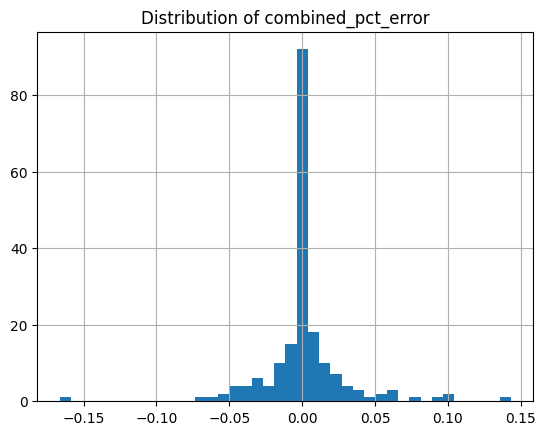

endowment_per_fte                   -0.741937
instruction_expense_pct              0.340330
student_service_expense_pct         -0.216720
avg_rank_stability                  -0.152971
employment_services                  0.142325
equity_ratio                         0.129143
study_abroad                        -0.096680
staff_per_student                   -0.092828
research_expense_pct                -0.078595
instructional_fte_per_student       -0.071706
irps_fte_per_student                -0.071017
weight                               0.054239
career_counseling                   -0.049182
instructional_staff_long_contract   -0.028384
instructional_staff_total           -0.028302
Name: combined_pct_error, dtype: float64


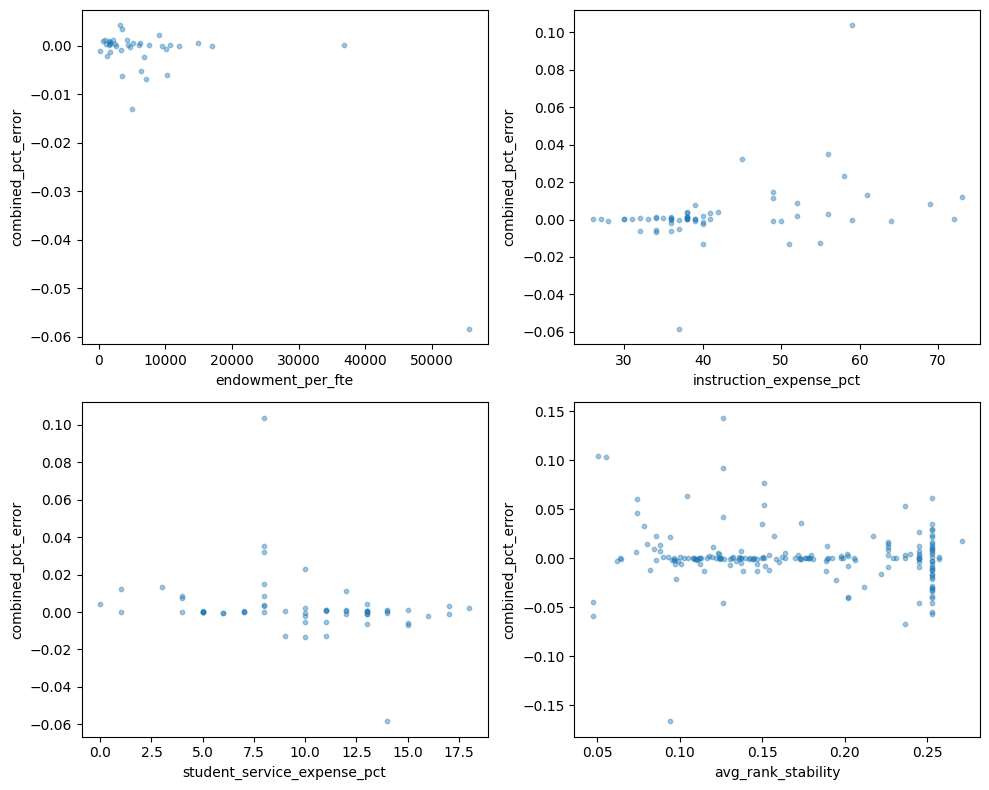

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. How does combined_pct_error actually distribute?
# Is it roughly normal, skewed, bimodal?
inst_model_df['combined_pct_error'].hist(bins=40)
plt.title("Distribution of combined_pct_error")
plt.show()

# 2. Simple correlation screen — what actually correlates with your target?
corr = inst_model_df.drop(columns=['school_name','unit_id'], errors='ignore') \
         .corr()['combined_pct_error'] \
         .drop('combined_pct_error') \
         .sort_values(key=abs, ascending=False)

print(corr.head(15))

# 3. Scatter the top 3-4 correlators against the target
top_features = corr.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(inst_model_df[feat], inst_model_df['combined_pct_error'], alpha=0.4, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('combined_pct_error')
plt.tight_layout()
plt.show()